In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

In [2]:
import csv
import os
import os.path as osp

## PubMed Dataset

In [3]:
df_nodes = pd.read_table(('PubMed/node.dat'),names=['node_id', 'node_name', 'node_type', 'node_attributes'],
                         quoting=csv.QUOTE_NONE)

In [4]:
df_labels_train = pd.read_table(('PubMed/label.dat'),
                                names=['node_id', 'node_name', 'node_type', 'node_label'])

In [5]:
df_labels_test = pd.read_table(('PubMed/label.dat.test'),
                               names=['node_id', 'node_name', 'node_type', 'node_label'])

In [6]:
df_labels = pd.concat([df_labels_train, df_labels_test],ignore_index=True)
df_labels.head()

,node_id,node_name,node_type,node_label
0,46178,psoriasis,1,6
1,60275,Skin_disease,1,6
2,16406,Nevus,1,6
3,52160,frambesia,1,6
4,46120,Erythroderma,1,6


In [7]:
#Select the nodes of type 1 which are labeled
df_disease=pd.merge(df_nodes, df_labels, on="node_id")[['node_id','node_attributes','node_label']]
df_disease = df_disease.reset_index()
df_disease.head()

,index,node_id,node_attributes,node_label
0,0,81,"0.293945,-1.118894,0.365789,0.826958,-1.024909...",2
1,1,382,"-0.076263,-0.1012,0.205599,-0.010939,0.011885,...",0
2,2,719,"-0.00509,-0.093002,0.155948,-1.041911,-0.11497...",1
3,3,1168,"-1.590567,-1.421712,1.546614,2.070439,-1.26965...",5
4,4,1183,"-0.047317,-0.141594,0.075213,-0.12674,-0.05318...",4


### Continuous features of 8 Disease node classes

In [8]:
def convert_string_to_float(df):
    return df['node_attributes'].apply(lambda x: np.fromstring(x, dtype=float, sep=',' ))

In [9]:
def preprocess_class(df_class):
    df_class = df_class.reset_index()
    df_class = convert_string_to_float(df_class)

    x = torch.tensor(df_class).float()
    disease_class = pd.DataFrame(x.numpy())
    return disease_class

In [10]:
class0 = df_disease[df_disease['node_label'] == 0].drop(['node_label','node_id'], axis = 1)
disease_class0 = preprocess_class(class0)
disease_class0.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.076263,-0.101200,0.205599,-0.010939,0.011885,-0.186806,0.017315,0.054221,-0.134682,0.029309,...,0.003725,-0.046961,0.022030,-0.059511,0.077090,0.027611,-0.119589,0.077600,-0.107299,0.150120
1,-0.105695,0.184201,-0.311365,-0.586918,0.041839,-0.375352,-0.209809,-0.275197,-0.187691,-0.010407,...,-0.295827,0.270551,0.139439,-0.118387,0.218033,0.240468,-0.405404,-0.024009,-0.038280,-0.079097
2,-0.027505,-0.145466,0.130640,-0.371549,0.082745,0.034039,-0.263921,0.326173,-0.230346,0.233040,...,-0.071879,-0.146309,0.144660,-0.052654,-0.092761,-0.082010,-0.002204,0.110625,-0.029077,-0.149880
3,-0.212835,0.020092,-0.067165,-0.360546,0.003719,-0.316084,-0.095670,-0.090671,-0.355869,0.123713,...,-0.042489,0.322580,0.213475,0.184327,0.126990,-0.174734,-0.356310,-0.022425,-0.208380,0.164806
4,0.176848,-0.177994,0.217688,-0.140722,-0.002420,-0.194984,-0.056105,0.126072,-0.111896,0.070906,...,-0.095619,-0.040588,0.164668,0.183074,-0.007102,-0.078018,-0.206885,-0.046569,-0.120863,0.097002


In [11]:
class1 = df_disease[df_disease['node_label'] == 1].drop(['node_label','node_id'], axis = 1)
disease_class1 = preprocess_class(class1)
disease_class1.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.005090,-0.093002,0.155948,-1.041911,-0.114979,-0.617497,0.166439,-0.113988,-0.443707,0.636185,...,-0.327394,0.439298,0.356134,0.690550,-0.308860,0.468901,0.244124,-0.058623,-0.368219,0.021397
1,0.678459,0.161107,-0.294408,-1.367651,2.103768,1.186129,1.882125,0.423219,-1.912892,1.194931,...,1.654857,1.608435,1.162236,-2.717319,-0.201214,1.197099,-1.264541,-2.922577,-1.188741,-1.307242
2,-1.681199,-0.703751,1.128087,-2.226594,-1.046119,0.636730,-0.500095,-0.239979,-0.998992,1.267447,...,2.065444,-1.046750,-2.627437,0.992201,0.717234,-2.367232,-2.050255,2.666933,-0.772199,0.401438
3,0.130749,-0.267213,1.721457,-0.982399,-0.044695,0.734526,-1.621730,0.373868,-0.232872,0.250372,...,-0.560398,0.781580,-0.162089,0.002168,0.013112,0.295674,-0.078259,0.097034,-0.650094,0.730890
4,0.465970,0.497691,-1.815122,-2.004339,-1.764053,-1.834500,0.539877,-1.023946,-1.697607,-0.490281,...,-0.737012,0.975823,-1.241157,0.261960,1.214548,-0.651538,-0.052915,-1.043717,-0.922041,1.584273


In [12]:
class2 = df_disease[df_disease['node_label'] == 2].drop(['node_label','node_id'], axis = 1)
disease_class2 = preprocess_class(class2)
disease_class2.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.293945,-1.118894,0.365789,0.826958,-1.024909,1.365870,-0.467886,0.515582,0.910748,1.669809,...,1.176890,-1.274171,-0.108948,-0.122850,0.121726,-0.147028,1.688417,-1.279368,-0.453393,-1.340375
1,-0.234695,-0.397418,-0.287049,-0.643192,-0.341378,-0.137831,0.152796,-0.083522,-0.232843,0.195185,...,0.211748,0.152090,0.104088,-0.103871,0.049093,0.222295,-0.139634,-0.290401,-0.421514,-0.226837
2,0.695679,-0.269031,-0.039114,-0.220264,0.207794,-0.019134,-0.248732,-0.059364,-0.408351,0.298378,...,0.260148,0.496637,-0.177052,-0.503436,0.183291,-0.307593,0.698607,0.043632,0.076104,0.478376
3,0.360314,-0.048848,0.084257,-0.308134,-0.118678,0.166424,-0.763351,0.002166,-0.790255,0.063675,...,-0.484946,0.004471,0.204809,-0.054277,0.325952,-0.179520,-0.097079,0.044739,-0.012146,-0.029781
4,-0.404648,-0.211988,0.180779,0.011021,0.246021,-0.108891,-0.292355,0.192935,-0.278896,0.114823,...,-0.048433,-0.053900,-0.057867,-0.046750,-0.020443,0.026236,-0.223835,-0.044477,-0.056810,-0.219431


In [13]:
class3 = df_disease[df_disease['node_label'] == 3].drop(['node_label','node_id'], axis = 1)
disease_class3 = preprocess_class(class3)
disease_class3.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.024643,0.083535,-0.118264,0.594446,-0.201284,-0.355791,-0.249425,0.963553,0.531981,0.146523,...,0.748214,0.242602,-0.510621,-1.191598,0.397599,-0.320266,0.024989,0.133490,1.125030,-0.851694
1,0.556467,-2.086023,1.777970,-0.953517,0.915395,1.392508,-1.678550,0.540311,1.287577,0.618743,...,-0.411275,0.044154,0.361089,-1.754970,0.017345,0.280704,-0.718187,-0.045025,-0.258995,-0.425449
2,0.399095,-0.033018,-0.050412,-0.308753,-0.270034,0.745800,0.109193,0.020682,0.472592,0.340427,...,0.173446,0.161498,0.315679,0.281295,-0.044803,0.013173,-0.458676,-0.137317,0.170523,0.214067
3,-0.240225,-1.536221,1.694471,0.427379,-1.573127,-1.249170,0.884610,0.263238,0.510730,1.645338,...,0.614007,0.541815,-2.998076,-2.450051,1.247795,-0.588532,3.193011,0.717154,0.347180,-1.627718
4,0.362348,-1.096200,0.676793,-0.413567,-0.772641,0.890930,-0.149459,0.236680,0.380899,0.178184,...,0.455985,-0.515523,0.660446,0.193103,0.302213,-0.151369,0.092068,0.212235,0.546388,0.454193


In [14]:
class4 = df_disease[df_disease['node_label'] == 4].drop(['node_label','node_id'], axis = 1)
disease_class4 = preprocess_class(class4)
disease_class4.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-0.047317,-0.141594,0.075213,-0.126740,-0.053180,-0.218182,0.010254,0.047152,-0.041381,0.002139,...,-0.163869,0.026139,0.029002,0.043187,0.089586,0.033324,-0.114441,-0.060817,-0.010271,0.124895
1,0.562200,-0.225132,1.403848,-0.900295,0.262917,0.775106,-1.395564,0.311257,-0.724682,0.510858,...,0.411451,0.706201,0.340969,0.616213,-0.581052,-0.016106,-0.312787,-0.254518,0.271065,-0.790870
2,0.132653,0.074229,0.130764,0.033300,-0.102414,-0.218270,-0.071465,0.149520,-0.059220,0.017269,...,-0.111331,0.032618,-0.101999,0.099495,0.009021,0.139706,-0.035738,0.021552,0.008510,0.002877
3,-0.017639,-0.033512,0.000192,-0.109765,0.026992,-0.011844,-0.011614,-0.025284,0.024664,0.010700,...,0.005757,0.102228,0.023747,0.007250,0.059213,0.070808,-0.047414,-0.096692,-0.043873,-0.066162
4,-0.131220,-0.051643,-0.041383,-0.281236,-0.046421,-0.136331,-0.069264,0.033541,-0.169223,0.180200,...,0.037729,-0.067685,0.098400,0.071199,0.224848,0.105085,-0.249451,-0.156987,-0.106818,0.112558


In [15]:
class5 = df_disease[df_disease['node_label'] == 5].drop(['node_label','node_id'], axis = 1)
disease_class5 = preprocess_class(class5)
disease_class5.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-1.590567,-1.421712,1.546614,2.070439,-1.269654,-3.492672,-0.985981,0.546692,-0.475412,-1.536833,...,0.422038,0.007902,-1.390627,-1.551006,0.566039,-0.957820,1.291253,-0.831003,-0.518681,-2.290930
1,1.707825,-0.382173,-1.978946,-0.982130,-0.596798,-1.058455,-0.786816,1.240825,-0.129001,0.208566,...,0.172373,3.154299,-0.672227,1.427703,1.280134,0.568588,-0.842362,-2.181951,1.627768,-0.607146
2,0.220100,-0.417449,-0.685131,0.271951,0.078659,-0.432255,0.099468,0.972583,0.090751,-0.106717,...,-0.402620,2.183498,-0.601318,1.458961,1.056984,0.751510,-1.148700,-1.398744,0.755516,-0.002951
3,-1.740684,0.606801,-1.877703,1.046687,0.026526,-0.971972,-0.062663,0.606383,-0.530064,-0.484855,...,0.776250,-1.420441,-0.033495,-0.917212,-0.367292,1.660141,-0.226066,1.478080,-0.249655,-0.803304
4,-0.115116,0.002367,-0.479038,-0.177523,0.033764,-0.129842,0.056449,-0.296631,-0.288493,-0.015120,...,-0.138466,-0.019240,-0.189517,-0.354875,0.412785,-0.289701,0.006733,0.096080,-0.055206,-0.724863


In [16]:
class6 = df_disease[df_disease['node_label'] == 6].drop(['node_label','node_id'], axis = 1)
disease_class6 = preprocess_class(class6)
disease_class6.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.705640,0.985807,1.727781,-0.572725,-1.510551,0.642899,-0.624731,-1.256330,0.380489,0.023940,...,0.237006,-0.864796,0.610489,0.725486,-0.615443,1.057366,-1.303320,-0.523200,-0.703197,0.300165
1,0.011111,-0.122398,0.108061,-0.168659,0.130440,-0.140680,-0.039575,0.006266,-0.134101,0.157674,...,-0.144526,0.049754,0.064575,0.282247,0.194395,0.082200,-0.225217,-0.088581,-0.127291,0.053279
2,1.179064,-0.248007,1.991181,0.059653,-1.148944,0.998520,-2.427823,0.023305,-1.135082,0.836730,...,0.554176,-0.339511,-0.320372,-0.973622,0.498973,0.603219,0.206073,-0.617010,0.398882,-0.659668
3,1.189486,-0.211165,1.973143,-0.170255,0.155388,0.033257,-1.330603,0.244563,-1.469571,0.941832,...,0.590651,-0.198665,0.922510,0.824605,-0.320789,-0.067372,-0.554014,-0.405515,-0.508741,-0.424119
4,0.355506,0.235083,0.229828,-0.683967,0.104608,-0.054153,-0.353290,-0.215031,-0.647038,0.664175,...,0.223206,-0.076717,0.368509,0.355019,-0.116577,0.160777,0.104109,-0.340245,-0.294386,0.067596


In [17]:
class7 = df_disease[df_disease['node_label'] == 7].drop(['node_label','node_id'], axis = 1)
disease_class7 = preprocess_class(class7)
disease_class7.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.008934,-0.107426,-0.025639,-0.182206,-0.061130,-0.204593,0.052291,0.000600,-0.019277,-0.035205,...,-0.004144,-0.114080,-0.111657,-0.027183,0.011316,0.052875,-0.172027,0.045929,-0.126126,0.006938
1,0.137979,-0.170588,0.379676,-0.133586,0.079844,-0.251604,-0.024294,-0.344566,0.012777,-0.011450,...,-0.218091,-0.112789,0.223476,0.009716,0.009727,-0.239896,-0.423860,0.127019,-0.208154,0.340889
2,-0.103373,-0.060679,0.032110,-0.060401,-0.028959,-0.040241,0.008029,0.002173,0.159710,0.096757,...,-0.051615,0.114342,-0.094867,0.182887,0.080529,0.035603,-0.051109,-0.036864,0.006196,-0.052524
3,-0.599056,-1.798572,0.036479,0.219410,-0.855767,-0.576619,1.906403,-1.219357,2.067185,-0.082776,...,0.970780,1.856780,-0.228110,0.857764,0.265307,0.256848,-0.150381,-0.285863,-1.042520,0.592658
4,1.363495,-0.065928,1.405803,-0.537324,-0.262326,-1.180556,0.268985,-0.565657,-0.405827,-1.344875,...,-0.853315,-0.385528,1.336321,0.695131,-0.434372,1.154994,0.586074,0.639965,-1.056659,-0.311664


### Features sampled using TabDDPM

In [18]:
#Reading from file the generated node features using diffusion

class0_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease0/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class1_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease1/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class2_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease2/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class3_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease3/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class4_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease4/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class5_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease5/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class6_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease6/ddpm_cb_best/X_num_train.npy',allow_pickle=True))
class7_syn  = pd.DataFrame(np.load('../tabddpm_y/exp/disease7/ddpm_cb_best/X_num_train.npy',allow_pickle=True))

In [19]:
class0_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,1.952247,-3.367060,-1.803416,1.010457,-1.476837,2.842493,-2.037548,-1.629064,-1.554717,2.184213,...,-0.679888,2.243484,-1.369766,-1.196172,0.936029,-2.770704,1.518045,-2.228798,0.483157,2.207631
1,-2.365893,0.790601,-1.803416,-3.049154,0.858770,-1.915434,-2.037548,2.917275,-1.554717,2.184213,...,2.333528,2.243484,1.500652,1.685660,0.936029,2.593532,1.518045,1.021764,0.483157,-3.080877
2,1.952247,-3.367060,-1.803416,1.010457,-1.476837,-1.915434,1.031644,-1.629064,-1.554717,2.184213,...,2.333528,2.243484,-1.369766,-1.196172,0.936029,-2.770704,-2.018928,1.021764,0.483157,2.207631
3,-2.365893,0.790601,2.124399,-3.049154,-1.476837,-1.915434,-2.037548,2.917275,1.645485,2.184213,...,2.333528,-1.544197,1.500652,1.685660,0.936029,-2.770704,1.518045,1.021764,-2.245831,2.207631
4,1.952247,0.790601,2.124399,-3.049154,0.858770,2.842493,1.031644,2.917275,-1.554717,-0.431390,...,2.333528,-1.544197,-1.369766,1.685660,0.936029,2.593532,-2.018928,-2.228798,-2.245831,2.207631


In [20]:
class1_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,2.368771,-1.166190,-1.815122,1.230877,-2.372598,-1.83450,1.882125,-1.124748,-2.424674,2.192679,...,-0.871355,1.989161,1.162236,-2.717319,1.679690,-2.367232,2.050598,3.370212,0.810170,1.584273
1,2.368771,1.987254,-1.815122,-3.919037,2.103768,1.83961,-2.051883,-1.124748,0.579256,2.192679,...,3.382916,1.989161,1.162236,1.608170,1.679690,2.175422,2.050598,-3.514298,0.810170,-2.488460
2,2.368771,1.987254,-1.815122,1.230877,-2.372598,-1.83450,1.882125,-1.124748,0.579256,2.192679,...,3.382916,1.989161,-2.941344,1.608170,-3.355048,-2.367232,2.050598,3.370212,0.810170,1.584273
3,-1.681199,1.987254,2.283153,-3.919037,-2.372598,-1.83450,-2.051883,1.295787,0.579256,2.192679,...,3.382916,-2.364772,-2.941344,1.608170,1.679690,-2.367232,2.050598,3.370212,-1.448032,1.584273
4,2.368771,1.987254,2.283153,-3.919037,2.103768,1.83961,1.882125,1.295787,-2.424674,-0.824571,...,3.382916,-2.364772,-2.941344,1.608170,1.679690,2.175422,-2.050255,-3.514298,-1.448032,1.584273


In [21]:
class2_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,2.502799,-1.584313,-1.682851,1.025930,-2.041530,1.365870,-2.403156,-2.207139,-2.00497,2.401393,...,-1.656027,1.485575,-2.693097,-1.470230,1.896802,-1.436505,1.688417,0.934719,1.442292,1.221990
1,-1.295192,0.332166,-1.682851,-2.367089,2.007043,-1.388929,-2.403156,-2.207139,-2.00497,2.401393,...,1.225072,1.485575,-2.693097,2.313936,1.896802,2.831682,1.688417,0.934719,1.442292,-1.840042
2,2.502799,-1.584313,-1.682851,1.025930,-2.041530,-1.388929,-2.403156,-2.207139,1.63682,2.401393,...,1.225072,1.485575,-2.693097,-1.470230,-1.536555,-1.436505,1.688417,0.934719,1.442292,1.221990
3,-1.295192,0.332166,-1.682851,-2.367089,-2.041530,-1.388929,0.551903,1.930324,1.63682,2.401393,...,1.225072,-1.663163,-2.693097,2.313936,1.896802,2.831682,1.688417,0.934719,-2.219665,1.221990
4,2.502799,0.332166,2.145310,-2.367089,2.007043,1.365870,0.551903,1.930324,-2.00497,-0.228863,...,-1.656027,-1.663163,-2.693097,2.313936,1.896802,2.831682,-0.514203,-1.326869,-2.219665,1.221990


In [22]:
class3_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,1.685758,-2.086023,-2.010161,0.705165,-2.092876,-1.249170,-1.678550,-0.603231,-0.706665,1.645338,...,-2.124724,2.674478,-2.998076,0.700092,1.247795,-0.588532,3.193011,1.045504,1.314373,0.759187
1,1.685758,1.690452,-2.010161,-1.251524,0.915395,-1.249170,-1.678550,-0.603231,-0.706665,1.645338,...,1.274587,2.674478,2.132479,-2.450051,1.247795,1.190244,3.193011,1.045504,1.314373,-3.180684
2,1.685758,-2.086023,-2.010161,0.705165,-2.092876,-1.249170,-1.678550,-0.603231,-0.706665,1.645338,...,1.274587,2.674478,-2.998076,-2.450051,-0.798908,-0.588532,3.193011,1.045504,1.314373,0.759187
3,-1.666802,1.690452,1.777970,-1.251524,-2.092876,-1.249170,2.590178,2.418433,1.751776,1.645338,...,1.274587,-1.056550,-2.998076,0.700092,1.247795,1.190244,3.193011,1.045504,-0.810886,0.759187
4,1.685758,1.690452,1.777970,-1.251524,-2.092876,1.392508,2.590178,2.418433,-0.706665,-1.389391,...,1.274587,-1.056550,-2.998076,0.700092,1.247795,1.190244,-1.157836,-1.512014,-0.810886,-3.180684


In [23]:
class4_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,2.812168,-3.047355,-0.315646,0.79588,-3.449349,2.049354,-2.370878,-0.531183,-3.373079,5.148929,...,-1.140319,1.237529,-0.581432,2.005333,0.695846,-1.161808,-1.618307,0.646046,1.359535,2.462089
1,2.812168,0.993596,-0.315646,0.79588,2.128868,-0.577357,-2.370878,-0.531183,0.220682,5.148929,...,0.616518,1.237529,-0.581432,2.005333,0.695846,2.603081,0.831554,0.646046,1.359535,-0.849606
2,2.812168,0.993596,-0.315646,0.79588,-3.449349,-0.577357,-2.370878,-0.531183,-3.373079,5.148929,...,0.616518,1.237529,-0.581432,-0.687242,-2.875029,-1.161808,0.831554,0.646046,1.359535,2.462089
3,-0.737306,0.993596,2.862979,-2.06367,-3.449349,-0.577357,0.769027,1.674170,0.220682,5.148929,...,0.616518,-1.784136,-0.581432,2.005333,-2.875029,2.603081,0.831554,0.646046,-1.274426,2.462089
4,2.812168,0.993596,-0.315646,-2.06367,2.128868,2.049354,0.769027,1.674170,-3.373079,-0.836927,...,0.616518,-1.784136,-0.581432,2.005333,0.695846,2.603081,0.831554,-2.096867,-1.274426,2.462089


In [24]:
class5_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,1.732121,1.19655,-2.069049,2.070439,0.817655,2.026547,1.335765,-1.406263,-3.768737,1.535390,...,-0.813545,-1.555037,-6.291446,-1.551006,-1.407136,2.058577,-1.209464,1.781627,-2.081823,2.389344
1,1.732121,1.19655,-2.069049,2.070439,0.817655,2.026547,1.335765,-1.406263,-3.768737,1.535390,...,-0.813545,-1.555037,-6.291446,-1.551006,1.405015,2.058577,-1.209464,-3.065625,2.390995,-3.208855
2,1.732121,1.19655,-2.069049,2.070439,-2.011376,-3.492672,1.335765,-1.406263,-3.768737,1.535390,...,-0.813545,-1.555037,-6.291446,-1.551006,-1.407136,-1.565629,-1.209464,1.781627,2.390995,2.389344
3,-2.213079,1.19655,2.427499,-1.926877,-2.011376,-3.492672,1.335765,2.152373,1.448905,1.535390,...,-0.813545,-1.555037,-6.291446,2.834130,1.405015,2.058577,1.291253,1.781627,-2.081823,2.389344
4,1.732121,1.19655,-2.069049,-1.926877,0.817655,2.026547,1.335765,-1.406263,-3.768737,-2.757788,...,-0.813545,-1.555037,-6.291446,2.834130,1.405015,2.058577,-1.209464,1.781627,-2.081823,2.389344


In [25]:
class6_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,1.386434,-0.85238,-1.283192,0.693007,-1.510551,1.270420,1.285921,-1.256330,-1.469571,0.941832,...,-1.293606,0.852487,-0.762335,-0.973622,0.737400,-0.609530,-2.451507,0.200962,0.398882,1.671030
1,-1.112951,1.07011,-1.283192,-1.570018,1.543399,-0.756668,-2.427823,0.677057,-1.469571,0.941832,...,1.620879,0.852487,1.582597,-0.973622,0.737400,2.072037,0.383771,-1.913786,0.398882,-1.178084
2,1.386434,1.07011,-1.283192,0.693007,-1.510551,-0.756668,-2.427823,-1.256330,-1.469571,0.941832,...,1.620879,0.852487,-0.762335,-0.973622,-1.060245,-0.609530,0.383771,0.200962,0.398882,1.671030
3,-1.112951,1.07011,2.840558,-1.570018,-1.510551,-0.756668,1.285921,0.677057,2.301008,0.941832,...,1.620879,-0.864796,-0.762335,2.098334,0.737400,-0.609530,0.383771,0.200962,-1.550965,1.671030
4,1.386434,1.07011,2.840558,-1.570018,1.543399,1.270420,1.285921,0.677057,-1.469571,-2.236691,...,1.620879,-0.864796,-0.762335,2.098334,0.737400,2.072037,-2.451507,-1.913786,-1.550965,1.671030


In [26]:
class7_syn.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,2.533713,1.572246,-1.173087,0.903614,-1.766807,-4.194458,-0.578528,-3.663668,-0.748121,1.382903,...,-0.853315,4.416382,-3.665129,1.474515,1.564342,-1.615710,2.504376,1.215078,0.770362,2.491769
1,2.533713,1.572246,-1.173087,-2.418904,1.656506,-4.194458,-0.578528,-3.663668,-0.748121,1.382903,...,2.463895,4.416382,-3.665129,-0.273548,1.564342,2.746542,2.504376,-1.557580,0.770362,-1.238514
2,2.533713,-3.397395,-1.173087,0.903614,-1.766807,-4.194458,-0.578528,-3.663668,2.213759,1.382903,...,2.463895,4.416382,-3.665129,-0.273548,-1.748719,-1.615710,2.504376,1.215078,0.770362,2.491769
3,-1.730652,1.572246,3.034477,-2.418904,-1.766807,-4.194458,2.995314,2.802083,2.213759,1.382903,...,2.463895,-0.385528,1.336321,1.474515,1.564342,2.746542,2.504376,1.215078,-3.404405,2.491769
4,2.533713,1.572246,3.034477,-2.418904,1.656506,1.855797,2.995314,2.802083,-0.748121,-1.344875,...,2.463895,-0.385528,-3.665129,1.474515,1.564342,2.746542,-1.443858,-1.557580,-3.404405,2.491769


### Pairwise cosine similarity of all features for real and synthetic distributions

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

Disease class 0

In [28]:
cosine_sim(disease_class0, class0_syn)

array([[ 0.1789583 ,  0.07515076,  0.04671238, ...,  0.14424007,
         0.06740045, -0.00221218],
       [ 0.15274216,  0.27259881,  0.11804202, ...,  0.23673332,
         0.08511646,  0.16505463],
       [ 0.16097411,  0.20789049,  0.12696908, ...,  0.17029569,
         0.17779619,  0.02861084],
       ...,
       [ 0.2276567 ,  0.27826221,  0.15456805, ...,  0.19547983,
         0.2331876 ,  0.08311642],
       [ 0.24869549,  0.20428461,  0.15719659, ...,  0.18637048,
         0.16388581,  0.02289704],
       [ 0.17648961,  0.2075389 , -0.0146006 , ...,  0.1331253 ,
         0.13899089,  0.0544338 ]])

In [29]:
sns.set(font_scale=1.4)

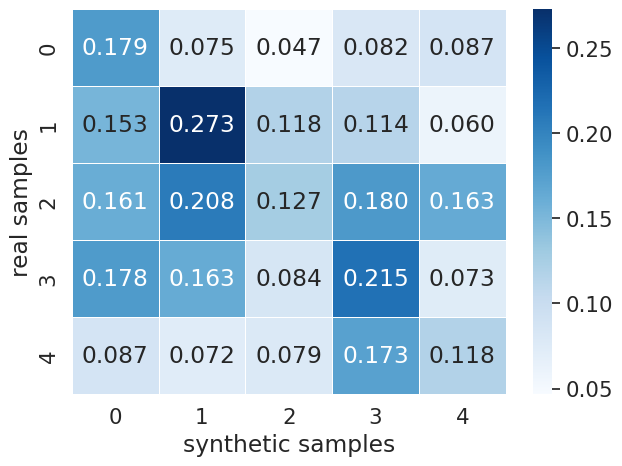

In [30]:
fig, ax = plt.subplots(figsize=(7,5)) 
sns.heatmap(cosine_sim(disease_class0[:5], class0_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [31]:
#Average cosine similarity for class 0
avg_cossim_class0 = np.mean(cosine_sim(disease_class0,class0_syn))
avg_cossim_class0

0.10724530170932832

Disease class 1

In [32]:
cosine_sim(disease_class1, class1_syn)

array([[ 0.09241317,  0.13605851, -0.04934718, ...,  0.19812964,
         0.01297509, -0.02758665],
       [ 0.17659016,  0.33547865,  0.08368628, ...,  0.15130848,
         0.13755871,  0.14850156],
       [ 0.15173676,  0.09870139,  0.05585994, ...,  0.06635163,
         0.15132949,  0.13032582],
       ...,
       [ 0.17023379,  0.28629431,  0.27340762, ...,  0.1365876 ,
         0.0579798 ,  0.12303508],
       [-0.00593669,  0.00575308,  0.06194916, ...,  0.03288142,
        -0.08654031, -0.04831355],
       [ 0.17344046,  0.24690331,  0.1164087 , ...,  0.05543539,
         0.08245978,  0.03854144]])

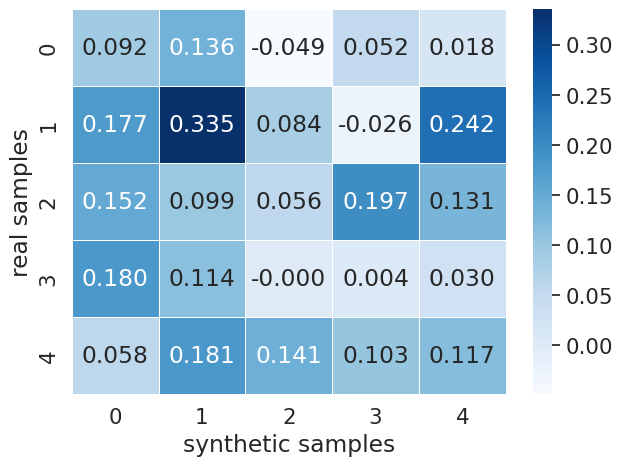

In [33]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class1[:5], class1_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [34]:
#Average cosine similarity for class 1
avg_cossim_class1 = np.mean(cosine_sim(disease_class1,class1_syn))
avg_cossim_class1

0.06416881380892225

Disease class 2

In [35]:
cosine_sim(disease_class2,class2_syn)

array([[ 0.07820194,  0.09043167, -0.00057352, ...,  0.15895105,
         0.00219817,  0.01801405],
       [ 0.05845127,  0.11033408,  0.08727431, ...,  0.10956893,
         0.05116045,  0.17983326],
       [ 0.2910446 ,  0.12118512,  0.20226905, ...,  0.01270833,
         0.23569062,  0.20187394],
       ...,
       [ 0.26524152,  0.11170981,  0.1830721 , ...,  0.01288359,
         0.12117634,  0.26457856],
       [ 0.06594619,  0.20630979,  0.06844664, ...,  0.07756327,
         0.07196523,  0.18946759],
       [ 0.17478791,  0.18112201,  0.11208494, ...,  0.13103906,
         0.17159296,  0.24936025]])

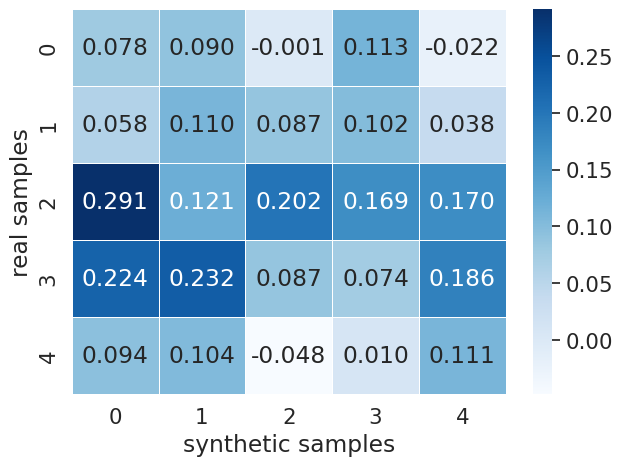

In [36]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class2[:5], class2_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [37]:
#Average cosine similarity for class 2
avg_cossim_class2 = np.mean(cosine_sim(disease_class2,class2_syn))
avg_cossim_class2

0.1201043344925604

Disease class 3

In [38]:
cosine_sim(disease_class3, class3_syn)

array([[ 0.12171575,  0.27065575,  0.15897117, ...,  0.24418242,
         0.16372289,  0.05869575],
       [ 0.09799122,  0.19882663,  0.13569591, ...,  0.20346503,
         0.27025526,  0.19090748],
       [ 0.0509444 ,  0.19453991,  0.13678491, ...,  0.03131214,
         0.20291682,  0.11159397],
       ...,
       [-0.00990445,  0.0402114 , -0.11391989, ..., -0.01194621,
        -0.03753067,  0.0368622 ],
       [ 0.05346111,  0.17672165,  0.03415072, ...,  0.02805322,
         0.26006493,  0.1373635 ],
       [ 0.02621736, -0.07298351, -0.01895353, ...,  0.17394973,
         0.02307408, -0.16374357]])

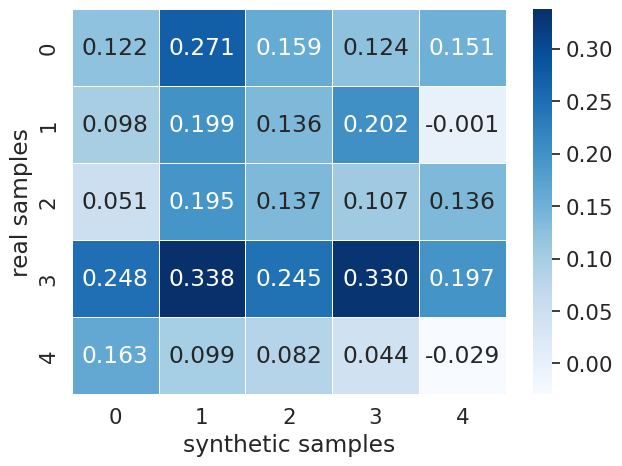

In [39]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class3[:5], class3_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [40]:
#Average cosine similarity for class 3
avg_cossim_class3 = np.mean(cosine_sim(disease_class3,class3_syn))
avg_cossim_class3

0.066103877394063

Disease class 4

In [41]:
cosine_sim(disease_class4, class4_syn)

array([[ 0.13226057,  0.14608159,  0.02328861, ...,  0.08375883,
         0.05859679,  0.11432832],
       [ 0.31894723,  0.25559152,  0.16628118, ...,  0.21516033,
         0.11204791,  0.12017581],
       [ 0.1038098 ,  0.26263238,  0.05819975, ...,  0.03115166,
        -0.03176478,  0.11127426],
       ...,
       [ 0.20671287,  0.25018809,  0.02468524, ...,  0.15354613,
         0.03730169,  0.23152909],
       [ 0.13899233,  0.21838542,  0.15529798, ...,  0.11498731,
         0.04543231,  0.23183822],
       [ 0.14418988,  0.21431729,  0.07079849, ...,  0.10190791,
         0.04323464,  0.04288977]])

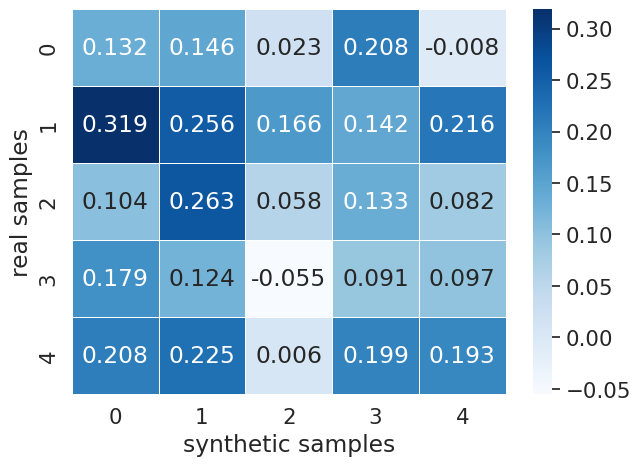

In [42]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class4[:5], class4_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [43]:
#Average cosine similarity for class 4
avg_cossim_class4 = np.mean(cosine_sim(disease_class4,class4_syn))
avg_cossim_class4

0.14761118530437

Disease class 5

In [44]:
cosine_sim(disease_class5, class5_syn)

array([[ 0.08423388,  0.09917135,  0.1269578 , ...,  0.21917661,
         0.23940217,  0.18858548],
       [-0.04116798,  0.04667557,  0.05978548, ...,  0.0742598 ,
         0.14916745,  0.00373128],
       [-0.05477909,  0.05114473,  0.04326267, ...,  0.04434282,
         0.10193716,  0.02209346],
       ...,
       [-0.05922886, -0.00533693,  0.00065256, ...,  0.05329319,
         0.03892456, -0.05943117],
       [-0.12036861, -0.07264055,  0.03147059, ..., -0.08706582,
         0.0907312 , -0.03295837],
       [ 0.00993145,  0.07684937,  0.07602487, ...,  0.06466804,
         0.08069589,  0.10374525]])

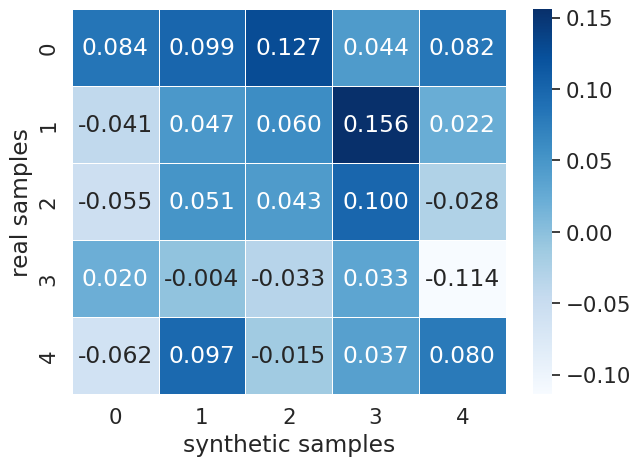

In [45]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class5[:5], class5_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [46]:
#Average cosine similarity for class 5
avg_cossim_class5 = np.mean(cosine_sim(disease_class5,class5_syn))
avg_cossim_class5

0.04859777252811663

Disease class 6

In [47]:
cosine_sim(disease_class6, class6_syn)

array([[0.32351805, 0.3334383 , 0.22248062, ..., 0.33371549, 0.28333859,
        0.35873437],
       [0.14657571, 0.30145871, 0.07400225, ..., 0.06553743, 0.13021467,
        0.22500634],
       [0.30448604, 0.3543801 , 0.26114653, ..., 0.26069876, 0.24257428,
        0.28643076],
       ...,
       [0.10756118, 0.12159089, 0.03423959, ..., 0.04231557, 0.09019232,
        0.07934645],
       [0.24621499, 0.17329124, 0.16947057, ..., 0.06727194, 0.27875301,
        0.23766717],
       [0.30718627, 0.37388482, 0.26486427, ..., 0.34335156, 0.31495724,
        0.27731892]])

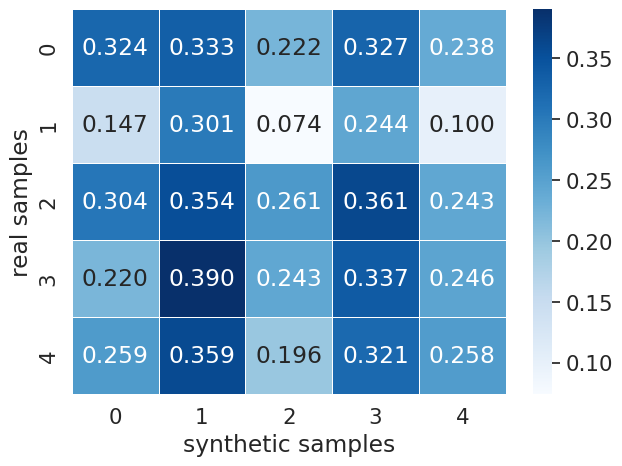

In [48]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class6[:5], class6_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [50]:
#Average cosine similarity for class 6
avg_cossim_class6 = np.mean(cosine_sim(disease_class6,class6_syn))
avg_cossim_class6

0.17654705475532692

Disease class 7

In [51]:
cosine_sim(disease_class7, class7_syn)

array([[0.07877856, 0.19060551, 0.01563795, ..., 0.09359902, 0.09503418,
        0.07485771],
       [0.23892798, 0.18811831, 0.23751029, ..., 0.22750964, 0.17110619,
        0.18906372],
       [0.11925882, 0.1641039 , 0.04422288, ..., 0.05148594, 0.15227317,
        0.03875195],
       ...,
       [0.19545139, 0.36036846, 0.35349444, ..., 0.25012575, 0.29129941,
        0.30893646],
       [0.19713642, 0.25440412, 0.271141  , ..., 0.16395151, 0.20039839,
        0.24668361],
       [0.27149757, 0.40121253, 0.33140569, ..., 0.16936048, 0.29752654,
        0.26031055]])

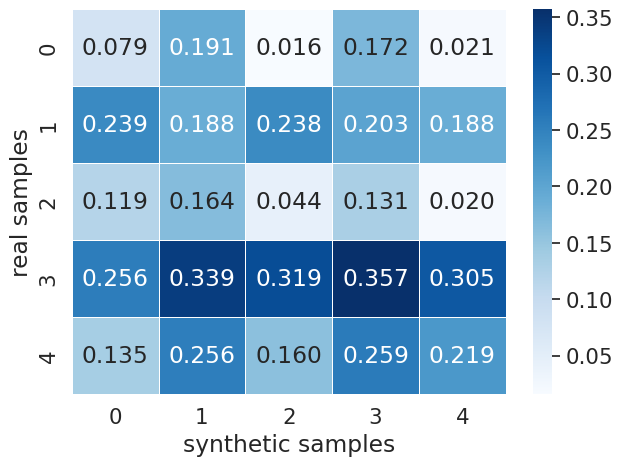

In [52]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cosine_sim(disease_class7[:5], class7_syn[:5]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues',fmt='.3f', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [53]:
#Average cosine similarity for class 7
avg_cossim_class7 = np.mean(cosine_sim(disease_class7,class7_syn))
avg_cossim_class7

0.17585724749685416

Average cosine similarity for all classes

In [54]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2 + avg_cossim_class3 + avg_cossim_class4 + 
 avg_cossim_class5 +avg_cossim_class6 + avg_cossim_class7)/8

0.11327944843619271